# Ex No 7 - Develop a python program for Motion Tracking 


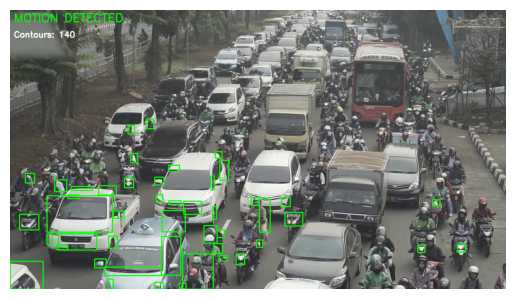

Motion Tracking Stopped


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

def main():

    # Video path
    video_path = r"C:\Users\91950\Downloads\t1.mp4"

    # Open video
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Could not open video file")
        return

    # Read first frame
    ret, first_frame = cap.read()
    if not ret:
        print("Error: Could not read video")
        return

    # Convert first frame to grayscale
    prev_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)
    prev_gray = cv2.GaussianBlur(prev_gray, (15, 15), 0)

    print("Motion Tracking Started...")

    while True:

        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to gray
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (15, 15), 0)

        # Frame difference
        frame_diff = cv2.absdiff(prev_gray, gray)

        # Threshold
        thresh = cv2.threshold(frame_diff, 15, 255, cv2.THRESH_BINARY)[1]

        # Dilate
        thresh = cv2.dilate(thresh, None, iterations=3)

        # Find contours
        contours, _ = cv2.findContours(
            thresh.copy(),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        motion_detected = False

        for contour in contours:

            area = cv2.contourArea(contour)

            if area > 200:
                motion_detected = True
                x, y, w, h = cv2.boundingRect(contour)

                cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)

        # Status text
        status = "MOTION DETECTED" if motion_detected else "No Motion"
        color = (0,255,0) if motion_detected else (0,0,255)

        cv2.putText(
            frame,
            status,
            (10,30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            color,
            2
        )

        cv2.putText(
            frame,
            f"Contours: {len(contours)}",
            (10,70),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255,255,255),
            2
        )

        # Convert BGR to RGB for matplotlib
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        clear_output(wait=True)
        plt.imshow(frame_rgb)
        plt.axis("off")
        display(plt.gcf())
        plt.close()

        # Update previous frame
        prev_gray = gray

    cap.release()
    print("Motion Tracking Stopped")

if __name__ == "__main__":
    main()